In [1]:
# SageMath 10.8 Script für die #Energiedoku
# Simulation der Cosmozetaology mittels Hurwitz-Quaternionen-Primzahlen

from sage.all import *

Q = QuaternionAlgebra(QQ, -1, -1)
i, j, k = Q.gens()
PLICHTA_STRAHLEN = [1, 5, 7, 11, 13, 17, 19, 23]


def hurwitz_werte(limit):
    """Erzeuge ganzzahlige und halbzahlinge Gitterwerte als rationale Sage-Zahlen."""
    return [QQ(n) / 2 for n in range(-2 * limit, 2 * limit + 1)]


def ist_hurwitz_punkt(coords):
    """Alle Komponenten sind entweder ganz oder alle strikt halbzahlig."""
    alle_ganz = all(x.is_integer() for x in coords)
    alle_halb = all((2 * x).is_integer() and not x.is_integer() for x in coords)
    return alle_ganz or alle_halb


def prime_hurwitz_norm(coords):
    """Gib die Primnorm eines Hurwitz-Punkts zurueck oder None."""
    a, b, c, d = coords
    q_val = a + b * i + c * j + d * k
    norm_val = ZZ(q_val.reduced_norm())
    if norm_val > 1 and is_prime(norm_val):
        return norm_val
    return None


def simuliere_quaternionen_kosmos(limit=10):
    """
    Simuliert einen 2D-Schnitt durch das 4D-Hurwitz-Gitter
    und markiert Punkte mit primzahliger Quaternionennorm.
    """
    resonanzo_punkte = []
    werte = hurwitz_werte(limit)

    print(f"Analysiere 4D-Gitter im Schnitt bis Koordinate {limit}...")

    for a in werte:
        for b in werte:
            coords = [a, b, QQ(0), QQ(0)]
            if not ist_hurwitz_punkt(coords):
                continue

            norm_val = prime_hurwitz_norm(coords)
            if norm_val is not None:
                resonanzo_punkte.append((a, b, norm_val))

    return resonanzo_punkte


# Durchführung der Schnitt-Simulation
ergebnisse = simuliere_quaternionen_kosmos(limit=5)

print(f"\nGefundene Resonanzpunkte (Schnitt): {len(ergebnisse)}")
print("-" * 50)
print("Auszug der Koordinaten (a, b) und deren energetische Norm:")
for p in ergebnisse[:10]:
    print(f"Koordinate: ({p[0]}, {p[1]}) -> Norm (Energie): {p[2]}")

# Interpretation für die #Energiedoku:
# Die Häufung dieser Punkte im 4D-Raum zeigt die "Primalität kosmischer Strukturen".

Analysiere 4D-Gitter im Schnitt bis Koordinate 5...

Gefundene Resonanzpunkte (Schnitt): 44
--------------------------------------------------
Auszug der Koordinaten (a, b) und deren energetische Norm:
Koordinate: (-5, -4) -> Norm (Energie): 41
Koordinate: (-5, -2) -> Norm (Energie): 29
Koordinate: (-5, 2) -> Norm (Energie): 29
Koordinate: (-5, 4) -> Norm (Energie): 41
Koordinate: (-4, -5) -> Norm (Energie): 41
Koordinate: (-4, -1) -> Norm (Energie): 17
Koordinate: (-4, 1) -> Norm (Energie): 17
Koordinate: (-4, 5) -> Norm (Energie): 41
Koordinate: (-3, -2) -> Norm (Energie): 13
Koordinate: (-3, 2) -> Norm (Energie): 13


In [2]:
# 4D-Erweiterung: Erfassung der fehlenden Plichta-Strahlen (7, 11, 19, 23)

def voll_quaternionen_kosmos(limit=3):
    """
    Simuliert das volle 4D-Gitter der Hurwitz-Primzahlen.
    Damit werden alle Plichta-Resonanzstrahlen modulo 24 erfasst,
    sofern sie innerhalb des gewaehlten Limits auftreten.
    """
    resonanz_register = {strahl: [] for strahl in PLICHTA_STRAHLEN}
    gefundene_normen = set()
    werte = hurwitz_werte(limit)

    print(f"Scanne 4D-Raumzeit-Gitter (Limit: {limit})...")

    for a in werte:
        for b in werte:
            for c in werte:
                for d in werte:
                    coords = [a, b, c, d]
                    if not ist_hurwitz_punkt(coords):
                        continue

                    norm_val = prime_hurwitz_norm(coords)
                    if norm_val is None:
                        continue

                    strahl = Integer(norm_val % 24)
                    if strahl in resonanz_register and norm_val not in gefundene_normen:
                        resonanz_register[strahl].append((tuple(coords), norm_val))
                        gefundene_normen.add(norm_val)

    return resonanz_register


# Vollstaendige 4D-Simulation starten
ergebnisse_4d = voll_quaternionen_kosmos(limit=4)

print("\n--- Analyse der 4D-Resonanzstrahlen (Modulo 24) ---")
for strahl in sorted(ergebnisse_4d.keys()):
    beispiele = ergebnisse_4d[strahl][:1]
    if beispiele:
        coords, norm_val = beispiele[0]
        print(
            f"Strahl {strahl:02d}: Resonanz gefunden bei Norm {norm_val} "
            f"(Koordinaten: {coords})"
        )
    else:
        print(f"Strahl {strahl:02d}: Keine Resonanz im gewaehlten Limit.")

Scanne 4D-Raumzeit-Gitter (Limit: 4)...

--- Analyse der 4D-Resonanzstrahlen (Modulo 24) ---
Strahl 01: Keine Resonanz im gewaehlten Limit.
Strahl 05: Resonanz gefunden bei Norm 29 (Koordinaten: (-4, -3, -2, 0))
Strahl 07: Resonanz gefunden bei Norm 31 (Koordinaten: (-7/2, -7/2, -5/2, -1/2))
Strahl 11: Resonanz gefunden bei Norm 11 (Koordinaten: (-3, -1, -1, 0))
Strahl 13: Resonanz gefunden bei Norm 37 (Koordinaten: (-4, -4, -2, -1))
Strahl 17: Resonanz gefunden bei Norm 41 (Koordinaten: (-4, -4, -3, 0))
Strahl 19: Resonanz gefunden bei Norm 43 (Koordinaten: (-4, -3, -3, -3))
Strahl 23: Resonanz gefunden bei Norm 23 (Koordinaten: (-7/2, -5/2, -3/2, -3/2))



--- Kompakte Strahl-Zusammenfassung ---
Strahl | Treffer | erste Primnorm | Beispielkoordinaten
------------------------------------------------------------------------
     1 |       0 |              - | -
     5 |       2 |             29 | (-4, -3, -2, 0)
     7 |       2 |             31 | (-7/2, -7/2, -5/2, -1/2)
    11 |       1 |             11 | (-3, -1, -1, 0)
    13 |       2 |             37 | (-4, -4, -2, -1)
    17 |       2 |             41 | (-4, -4, -3, 0)
    19 |       2 |             43 | (-4, -3, -3, -3)
    23 |       1 |             23 | (-7/2, -5/2, -3/2, -3/2)

Aktive Strahlen: [5, 7, 11, 13, 17, 19, 23]
Fehlende Strahlen im aktuellen Limit: [1]


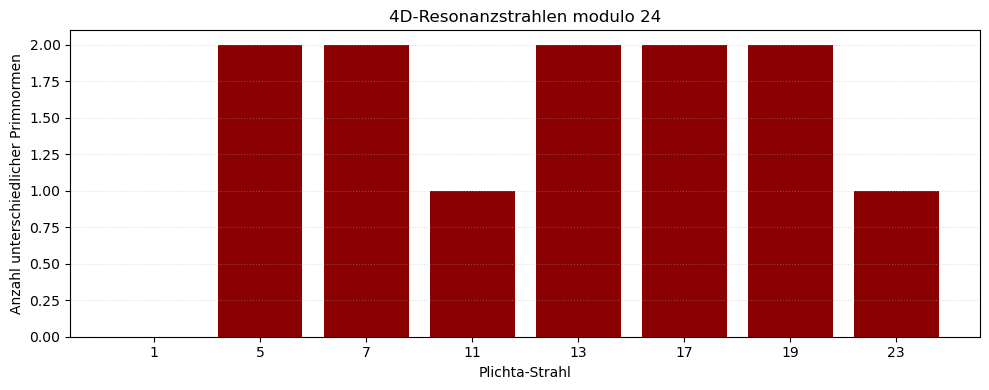

In [3]:
# Kompakte Zusammenfassung der 4D-Resonanzstrahlen

strahl_daten = []
for strahl in sorted(PLICHTA_STRAHLEN):
    treffer = ergebnisse_4d[strahl]
    anzahl = len(treffer)
    erste_norm = int(treffer[0][1]) if treffer else None
    erste_coords = treffer[0][0] if treffer else None
    strahl_daten.append((strahl, anzahl, erste_norm, erste_coords))

print("\n--- Kompakte Strahl-Zusammenfassung ---")
print("Strahl | Treffer | erste Primnorm | Beispielkoordinaten")
print("-" * 72)
for strahl, anzahl, erste_norm, erste_coords in strahl_daten:
    norm_text = f"{erste_norm}" if erste_norm is not None else "-"
    coords_text = f"{erste_coords}" if erste_coords is not None else "-"
    print(f"{strahl:>6} | {anzahl:>7} | {norm_text:>14} | {coords_text}")

aktive_strahlen = [strahl for strahl, anzahl, _, _ in strahl_daten if anzahl > 0]
fehlende_strahlen = [strahl for strahl, anzahl, _, _ in strahl_daten if anzahl == 0]

print("\nAktive Strahlen:", aktive_strahlen)
print("Fehlende Strahlen im aktuellen Limit:", fehlende_strahlen if fehlende_strahlen else "keine")

try:
    import matplotlib.pyplot as plt

    labels = [str(strahl) for strahl, _, _, _ in strahl_daten]
    werte = [anzahl for _, anzahl, _, _ in strahl_daten]
    farben = ["darkred" if anzahl > 0 else "lightgray" for anzahl in werte]

    plt.figure(figsize=(10, 4))
    plt.bar(labels, werte, color=farben)
    plt.title("4D-Resonanzstrahlen modulo 24")
    plt.xlabel("Plichta-Strahl")
    plt.ylabel("Anzahl unterschiedlicher Primnormen")
    plt.grid(axis="y", linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Matplotlib ist nicht verfuegbar; die Textzusammenfassung wurde trotzdem erzeugt.")

In [4]:
# Gezielte Suchraum-Optimierung fuer den fehlenden Strahl 1 modulo 24


def familien_werte(limit, halbzahl=False):
    """Erzeuge nichtnegative Betragswerte einer Hurwitz-Familie."""
    limit = int(ZZ(limit))
    if halbzahl:
        return [QQ(2 * n + 1) / 2 for n in range(limit)]
    return [QQ(n) for n in range(limit + 1)]


def restklassen_summen(skalen_reste, modulo, max_slots=4):
    """Moegliche Restklassen fuer Summen aus 0..max_slots Beitragen modulo 'modulo'."""
    modulo = Integer(modulo)
    max_slots = int(ZZ(max_slots))
    restklassen = [set([Integer(0)])]
    for slots in range(1, max_slots + 1):
        neue_klassen = set()
        for rest in restklassen[slots - 1]:
            for skalen_rest in skalen_reste:
                neue_klassen.add(Integer((rest + skalen_rest) % modulo))
        restklassen.append(neue_klassen)
    return restklassen


def suche_strahl_mit_pruning(limit=6, zielstrahl=1, max_treffer=5):
    """
    Suche gezielt nach Hurwitz-Primnormen im gewuenschten Strahl modulo 24.

    Optimierungen:
    - Symmetrie-Reduktion auf sortierte nichtnegative Betragskoordinaten
    - Kongruenz-Pruning ueber moegliche Restklassen der verbleibenden Quadrate

    Fuer die halbzahlige Familie arbeiten wir mit der skalierten Norm 4*N modulo 96,
    damit auch Viertelquadrate sauber in die Kongruenzrechnung eingehen.
    """
    limit = int(ZZ(limit))
    zielstrahl = Integer(zielstrahl)
    max_treffer = int(ZZ(max_treffer))

    statistiken = {
        "knoten": 0,
        "residuen_pruned": 0,
        "normtests": 0,
    }
    treffer = []
    gesehene_normen = set()

    for familienname, basiswerte in [
        ("ganzzahlig", familien_werte(limit, halbzahl=False)),
        ("halbzahlig", familien_werte(limit, halbzahl=True)),
    ]:
        quadrate = [wert**2 for wert in basiswerte]
        skalen_quadrate = [ZZ(4 * quadrat) for quadrat in quadrate]
        skalen_reste = [Integer(skalen_quadrat % 96) for skalen_quadrat in skalen_quadrate]
        moegliche_reste = restklassen_summen(skalen_reste, modulo=96, max_slots=4)
        ziel_rest_skaliert = Integer((4 * zielstrahl) % 96)

        def rekursion(start_index, tiefe, partial_mod_skaliert, coords):
            statistiken["knoten"] += 1
            verbleibend = 4 - tiefe
            benoetigter_rest = Integer((ziel_rest_skaliert - partial_mod_skaliert) % 96)

            if benoetigter_rest not in moegliche_reste[verbleibend]:
                statistiken["residuen_pruned"] += 1
                return

            if tiefe == 4:
                statistiken["normtests"] += 1
                kandidat = tuple(reversed(coords))
                norm_val = prime_hurwitz_norm(kandidat)
                if (
                    norm_val is not None
                    and Integer(norm_val % 24) == zielstrahl
                    and norm_val not in gesehene_normen
                ):
                    treffer.append((kandidat, Integer(norm_val), familienname))
                    gesehene_normen.add(norm_val)
                return

            for index in range(start_index, len(basiswerte)):
                if len(treffer) >= max_treffer:
                    return

                wert = basiswerte[index]
                q_rest = skalen_reste[index]
                rekursion(
                    index,
                    tiefe + 1,
                    Integer((partial_mod_skaliert + q_rest) % 96),
                    coords + [wert],
                )

        rekursion(0, 0, Integer(0), [])
        if len(treffer) >= max_treffer:
            break

    return treffer, statistiken


such_limit = Integer(6)
strahl1_treffer, pruning_statistik = suche_strahl_mit_pruning(
    limit=such_limit,
    zielstrahl=Integer(1),
    max_treffer=Integer(5),
)

print(f"\n--- Gezielte Strahl-1-Suche mit Pruning (Limit {such_limit}) ---")
if strahl1_treffer:
    for nummer, (coords, norm_val, familienname) in enumerate(strahl1_treffer, start=1):
        print(
            f"Treffer {nummer}: Norm {norm_val} im Strahl 01 "
            f"({familienname}, Koordinaten: {coords})"
        )
else:
    print("Kein Treffer fuer Strahl 01 im gewaehlten Limit gefunden.")

naive_hurwitz_punkte = (2 * int(ZZ(such_limit)) + 1) ** 4 + (2 * int(ZZ(such_limit))) ** 4

print("\nSuchstatistik:")
for name, wert in pruning_statistik.items():
    print(f"- {name}: {wert}")
print(f"- naive Hurwitz-Punkte ohne Pruning: {naive_hurwitz_punkte}")
if pruning_statistik["normtests"] > 0:
    reduktionsfaktor = QQ(naive_hurwitz_punkte) / pruning_statistik["normtests"]
    print(f"- Reduktionsfaktor bei Normtests: {float(reduktionsfaktor):.1f}x")


--- Gezielte Strahl-1-Suche mit Pruning (Limit 6) ---
Treffer 1: Norm 73 im Strahl 01 (ganzzahlig, Koordinaten: (6, 6, 1, 0))
Treffer 2: Norm 97 im Strahl 01 (ganzzahlig, Koordinaten: (6, 6, 5, 0))

Suchstatistik:
- knoten: 302
- residuen_pruned: 167
- normtests: 26
- naive Hurwitz-Punkte ohne Pruning: 49297
- Reduktionsfaktor bei Normtests: 1896.0x



--- Energetische Signatur des aktuellen Monats ---
Datum: 2026-04-18
Monatscode modulo 24: 14
Gesamtenergieindex: 0.16
Dominanter Strahl: 13 mit Anteil 32.%

Strahl | Treffer | Distanz | Kopplung | Energieanteil
------------------------------------------------------------------------
     1 |       2 |      11 |    0.082 |         1.2%
     5 |       2 |       9 |     0.10 |          14%
     7 |       2 |       7 |     0.12 |          14%
    11 |       1 |       3 |     0.25 |          14%
    13 |       2 |       1 |     0.50 |          32%
    17 |       2 |       3 |     0.25 |          13%
    19 |       2 |       5 |     0.16 |         8.0%
    23 |       1 |       9 |     0.10 |         2.8%


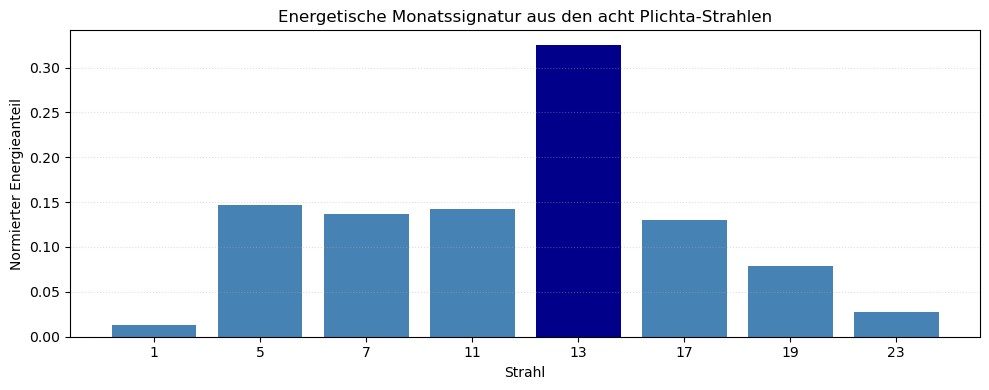

In [5]:
# Energetische Signatur des aktuellen Monats auf Basis aller acht Strahlen

from datetime import date


def kombiniertes_resonanz_register(basis_register, zusatz_treffer=None):
    """Fuehre das 4D-Register mit gezielten Zusatztreffern zusammen."""
    register = {strahl: list(basis_register.get(strahl, [])) for strahl in PLICHTA_STRAHLEN}
    bekannte_normen = {
        strahl: {Integer(norm_val) for _, norm_val in register[strahl]}
        for strahl in PLICHTA_STRAHLEN
    }

    if zusatz_treffer:
        for coords, norm_val, _familie in zusatz_treffer:
            strahl = Integer(norm_val % 24)
            if strahl in register and norm_val not in bekannte_normen[strahl]:
                register[strahl].append((tuple(coords), Integer(norm_val)))
                bekannte_normen[strahl].add(Integer(norm_val))

    for strahl in PLICHTA_STRAHLEN:
        register[strahl].sort(key=lambda eintrag: Integer(eintrag[1]))

    return register


def zyklische_distanz_mod24(a, b):
    """Kleinste zyklische Distanz zweier Klassen modulo 24."""
    diff = abs(int(ZZ(a)) - int(ZZ(b))) % 24
    return min(diff, 24 - diff)


def monats_signatur(resonanz_register, ziel_datum=None):
    """
    Berechne ein reproduzierbares Monatsprofil aus den aktiven Strahlen.

    Modell:
    - Monatscode = (Jahr + Monat) modulo 24
    - Strahlintensitaet = Summe der inversen Primnormen pro Strahl
    - Monatskopplung = 1 / (1 + zyklische Distanz zum Monatscode)
    - Signaturanteil = Intensitaet * Monatskopplung
    """
    if ziel_datum is None:
        ziel_datum = date.today()

    monatscode = Integer((ziel_datum.year + ziel_datum.month) % 24)
    signatur = []

    for strahl in PLICHTA_STRAHLEN:
        normen = [Integer(norm_val) for _, norm_val in resonanz_register[strahl]]
        intensitaet = sum((QQ(1) / norm_val for norm_val in normen), QQ(0))
        distanz = zyklische_distanz_mod24(strahl, monatscode)
        kopplung = QQ(1) / Integer(distanz + 1)
        beitrag = intensitaet * kopplung
        signatur.append(
            {
                "strahl": Integer(strahl),
                "anzahl": len(normen),
                "normen": normen,
                "intensitaet": intensitaet,
                "distanz": distanz,
                "kopplung": kopplung,
                "beitrag": beitrag,
            }
        )

    gesamtenergie = sum((eintrag["beitrag"] for eintrag in signatur), QQ(0))
    for eintrag in signatur:
        if gesamtenergie > 0:
            eintrag["anteil"] = eintrag["beitrag"] / gesamtenergie
        else:
            eintrag["anteil"] = QQ(0)

    dominanter_strahl = max(signatur, key=lambda eintrag: eintrag["beitrag"])
    return {
        "datum": ziel_datum,
        "monatscode": monatscode,
        "gesamtenergie": gesamtenergie,
        "dominanter_strahl": dominanter_strahl,
        "signatur": signatur,
    }


vollregister_8 = kombiniertes_resonanz_register(ergebnisse_4d, strahl1_treffer)
aktuelle_signatur = monats_signatur(vollregister_8)

print("\n--- Energetische Signatur des aktuellen Monats ---")
print(f"Datum: {aktuelle_signatur['datum']}")
print(f"Monatscode modulo 24: {aktuelle_signatur['monatscode']}")
print(f"Gesamtenergieindex: {N(aktuelle_signatur['gesamtenergie'], 8)}")
print(
    "Dominanter Strahl: "
    f"{aktuelle_signatur['dominanter_strahl']['strahl']:02d} "
    f"mit Anteil {N(100 * aktuelle_signatur['dominanter_strahl']['anteil'], 4)}%"
)

print("\nStrahl | Treffer | Distanz | Kopplung | Energieanteil")
print("-" * 72)
for eintrag in aktuelle_signatur["signatur"]:
    print(
        f"{eintrag['strahl']:>6} | {eintrag['anzahl']:>7} | {eintrag['distanz']:>7} | "
        f"{N(eintrag['kopplung'], 5):>8} | {N(100 * eintrag['anteil'], 5):>11}%"
    )

try:
    import matplotlib.pyplot as plt

    labels = [str(eintrag["strahl"]) for eintrag in aktuelle_signatur["signatur"]]
    anteile = [float(eintrag["anteil"]) for eintrag in aktuelle_signatur["signatur"]]
    farben = ["darkblue" if eintrag["strahl"] == aktuelle_signatur["dominanter_strahl"]["strahl"] else "steelblue" for eintrag in aktuelle_signatur["signatur"]]

    plt.figure(figsize=(10, 4))
    plt.bar(labels, anteile, color=farben)
    plt.title("Energetische Monatssignatur aus den acht Plichta-Strahlen")
    plt.xlabel("Strahl")
    plt.ylabel("Normierter Energieanteil")
    plt.grid(axis="y", linestyle=":", alpha=0.4)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Matplotlib ist nicht verfuegbar; die Textsignatur wurde trotzdem berechnet.")


--- Dynamische Zeitreihen-Simulation gestartet ---
Start-Phase: 14.00 (aktueller Monatscode)
Kaempfende Resonanzen: Strahl 13 vs. Strahl 5
--------------------------------------------------
>>> ENERGETISCHER KIPPPUNKT <<<
Simulationsschritte: 70
Kritischer Phasen-Code (Modulo 24): 21.00
Energie Strahl 13: 0.0588
Energie Strahl 5: 0.0588
--------------------------------------------------


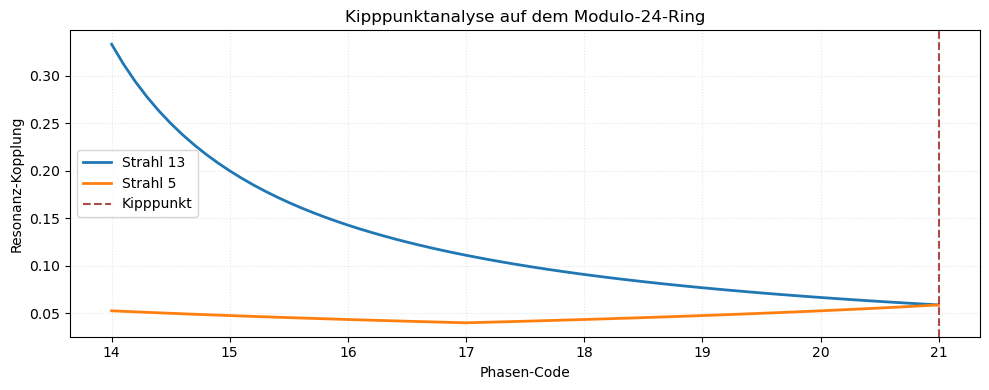

In [6]:
# Dynamische Zeitreihenanalyse: Kipppunkt von Strahl 13 zu Strahl 5


def ring_distanz(x, y, modulo=24):
    """Berechne die kuerzeste Distanz auf dem zirkulaeren Restklassenring."""
    x_mod = float(x) % modulo
    y_mod = float(y) % modulo
    differenz = abs(x_mod - y_mod)
    return min(differenz, modulo - differenz)


def berechne_kopplung(code, strahl, kopplungs_konstante=0.5, epsilon=0.5):
    """Inverse Distanzgewichtung fuer einen kontinuierlichen Phasencode."""
    distanz = ring_distanz(code, strahl)
    return float(kopplungs_konstante) / (distanz + float(epsilon))


def finde_kipppunkt(
    start_code=None,
    ziel_strahl=5,
    dominanter_strahl=13,
    schrittweite=0.1,
    kopplungs_konstante=0.5,
    epsilon=0.5,
    max_schritte=1000,
):
    """
    Simuliere die Vorwaertsbewegung auf dem Modulo-24-Ring und finde den
    Schnittpunkt der Kopplungskurven von dominantem und Zielstrahl.
    """
    if start_code is None:
        start_code = float(aktuelle_signatur["monatscode"])
    else:
        start_code = float(start_code)

    ziel_strahl = int(ZZ(ziel_strahl))
    dominanter_strahl = int(ZZ(dominanter_strahl))
    schrittweite = float(schrittweite)

    verlauf = []
    vorherige_differenz = None
    kipppunkt = None

    aktueller_code = start_code
    for schritt in range(int(max_schritte) + 1):
        energie_dominant = berechne_kopplung(
            aktueller_code,
            dominanter_strahl,
            kopplungs_konstante=kopplungs_konstante,
            epsilon=epsilon,
        )
        energie_ziel = berechne_kopplung(
            aktueller_code,
            ziel_strahl,
            kopplungs_konstante=kopplungs_konstante,
            epsilon=epsilon,
        )
        differenz = energie_ziel - energie_dominant

        verlauf.append(
            {
                "schritt": schritt,
                "code": aktueller_code % 24,
                "energie_dominant": energie_dominant,
                "energie_ziel": energie_ziel,
                "differenz": differenz,
            }
        )

        if abs(differenz) < 1e-12:
            kipppunkt = verlauf[-1]
            break

        if vorherige_differenz is not None and vorherige_differenz < 0 <= differenz:
            kipppunkt = verlauf[-1]
            break

        vorherige_differenz = differenz
        aktueller_code = (aktueller_code + schrittweite) % 24
    else:
        raise RuntimeError("Kipppunkt im gewaehlten Suchfenster nicht gefunden.")

    return {
        "start_code": start_code,
        "ziel_strahl": ziel_strahl,
        "dominanter_strahl": dominanter_strahl,
        "schrittweite": schrittweite,
        "kipppunkt": kipppunkt,
        "verlauf": verlauf,
    }


zeitanalyse = finde_kipppunkt(
    start_code=float(aktuelle_signatur["monatscode"]),
    ziel_strahl=5,
    dominanter_strahl=int(aktuelle_signatur["dominanter_strahl"]["strahl"]),
    schrittweite=0.1,
)

kipppunkt = zeitanalyse["kipppunkt"]
print("\n--- Dynamische Zeitreihen-Simulation gestartet ---")
print(f"Start-Phase: {zeitanalyse['start_code']:.2f} (aktueller Monatscode)")
print(
    f"Kaempfende Resonanzen: Strahl {zeitanalyse['dominanter_strahl']} "
    f"vs. Strahl {zeitanalyse['ziel_strahl']}"
)
print("-" * 50)
print(
    f">>> ENERGETISCHER KIPPPUNKT <<<\n"
    f"Simulationsschritte: {kipppunkt['schritt']}\n"
    f"Kritischer Phasen-Code (Modulo 24): {kipppunkt['code']:.2f}\n"
    f"Energie Strahl {zeitanalyse['dominanter_strahl']}: {kipppunkt['energie_dominant']:.4f}\n"
    f"Energie Strahl {zeitanalyse['ziel_strahl']}: {kipppunkt['energie_ziel']:.4f}"
)
print("-" * 50)

try:
    import matplotlib.pyplot as plt

    codes = [punkt["code"] for punkt in zeitanalyse["verlauf"]]
    dominant_kurve = [punkt["energie_dominant"] for punkt in zeitanalyse["verlauf"]]
    ziel_kurve = [punkt["energie_ziel"] for punkt in zeitanalyse["verlauf"]]

    plt.figure(figsize=(10, 4))
    plt.plot(codes, dominant_kurve, label=f"Strahl {zeitanalyse['dominanter_strahl']}", linewidth=2)
    plt.plot(codes, ziel_kurve, label=f"Strahl {zeitanalyse['ziel_strahl']}", linewidth=2)
    plt.axvline(kipppunkt["code"], color="darkred", linestyle="--", alpha=0.7, label="Kipppunkt")
    plt.title("Kipppunktanalyse auf dem Modulo-24-Ring")
    plt.xlabel("Phasen-Code")
    plt.ylabel("Resonanz-Kopplung")
    plt.grid(alpha=0.3, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Matplotlib ist nicht verfuegbar; die Zeitreihenanalyse wurde ohne Grafik berechnet.")

Plot wurde erfolgreich als 'kipppunkt_2026.pdf' generiert.
Verwendeter Kipppunkt aus der Zeitreihenanalyse: 21.00


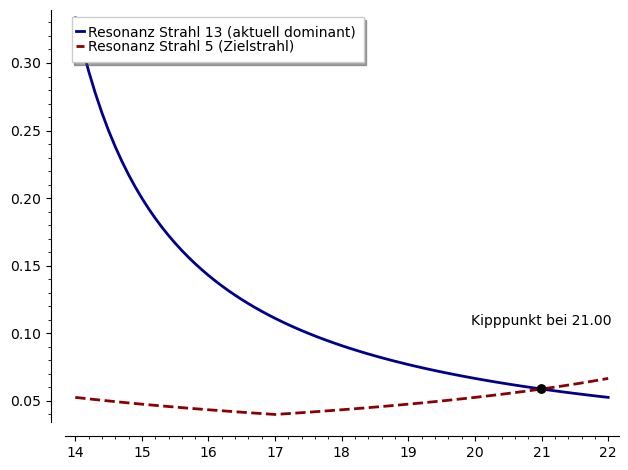

In [7]:
# Plot-Generierung: Der energetische Kipppunkt (Strahl 13 vs. Strahl 5)

# Wir verwenden die bereits berechnete Zeitreihenanalyse, damit der Plot
# exakt zum simulierten Vorwaertslauf ab dem aktuellen Monatscode passt.
start_code = zeitanalyse["start_code"]
schrittweite_plot = zeitanalyse["schrittweite"]
kipppunkt_x = zeitanalyse["kipppunkt"]["code"]
ziel_strahl = zeitanalyse["ziel_strahl"]
dominanter_strahl = zeitanalyse["dominanter_strahl"]

# Das Plotfenster reicht etwas ueber den Kipppunkt hinaus, damit der Uebergang sichtbar bleibt.
plot_ende = kipppunkt_x + 1.0
x_werte = srange(start_code, plot_ende + schrittweite_plot / 2, schrittweite_plot)
y_strahl_dominant = [berechne_kopplung(x, dominanter_strahl) for x in x_werte]
y_strahl_ziel = [berechne_kopplung(x, ziel_strahl) for x in x_werte]

plot_dominant = list_plot(
    list(zip(x_werte, y_strahl_dominant)),
    color="darkblue",
    plotjoined=True,
    thickness=2,
    legend_label=f"Resonanz Strahl {dominanter_strahl} (aktuell dominant)",
)

plot_ziel = list_plot(
    list(zip(x_werte, y_strahl_ziel)),
    color="darkred",
    plotjoined=True,
    thickness=2,
    linestyle="--",
    legend_label=f"Resonanz Strahl {ziel_strahl} (Zielstrahl)",
)

final_plot = plot_dominant + plot_ziel
final_plot.axes_labels(["Zeitlicher Phasen-Code (Modulo 24)", "Energetische Kopplung"])
final_plot.set_legend_options(loc="upper left")
final_plot.fontsize(12)

kipppunkt_y = berechne_kopplung(kipppunkt_x, dominanter_strahl)
final_plot += point((kipppunkt_x, kipppunkt_y), color="black", size=50, zorder=10)
final_plot += text(
    f"Kipppunkt bei {kipppunkt_x:.2f}",
    (kipppunkt_x, kipppunkt_y + 0.05),
    color="black",
    fontsize=10,
)

plot_datei = "kipppunkt_2026.pdf"
final_plot.save(plot_datei)
print(f"Plot wurde erfolgreich als '{plot_datei}' generiert.")
print(f"Verwendeter Kipppunkt aus der Zeitreihenanalyse: {kipppunkt_x:.2f}")
final_plot.show()